# Adaptive Recovery Algorithm 
**April 2026**

Here we implement the updated adaptive recovery protocol, where the system's state collapses due to the measurement outcome on the ancilla.

## Fixed Choices
- `N qubits`: 1
- `Noises`: Amplitude Damping (60\%) / Dephasing (40\%)



In [46]:
using Pkg
Pkg.activate(joinpath(pwd(), "..", "julia"))
Pkg.instantiate()   # optional after first time

  Activating project at `~/UNIPA/COLLISION_MODELS/shooting-decoherences/julia`


In [ ]:
using LinearAlgebra
using Plots
using Revise
using Latexify

using Random
using StatsBase

using Printf

# ==============================================
# Custom logger
using Logging, TerminalLoggers, ProgressLogging
# Display debug messages
global_logger(TerminalLogger(stderr, Logging.Info))
debuglogger = ConsoleLogger(stderr, Logging.Debug)

includet("../julia/src/logging.jl")
# ==============================================

includet("../julia/src/UnitaryDilation/UnitaryDilation.jl")
includet("../julia/src/PetzMaps.jl")
# includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
includet("../julia/src/configurations.jl")
includet("../julia/src/custom_plots.jl")

using .UnitaryDilation
# using .DecoKiller
using .PetzMaps

In [48]:
function get_kraus_operators(noise, gamma, t)
  if noise == "amplitude_damping"
    return get_amplitudedamping_operators(gamma, t)
  elseif noise == "dephasing"
    return get_phasedamping_operators(gamma, t)
  elseif noise == "bitflip"
    return get_bitflip_operators(gamma, t)
  else
    error("Unknown noise model: $noise")
  end

end

function apply_noise(model, ρ, n_qubits)
  ρf = apply_channel(model.kraus_fwd, ρ, n_qubits)
  # Enforce physicality (hermitianicity and trace 1)
  # enforce_physical!(ρf)
  return ρf
end


function recovery(model, ρ)
  ρr, η = apply_collision(model, ρ)
  # enforce_physical!(ρr)
  return ρr, η
end

recovery (generic function with 1 method)

## Setup

In [49]:
n_qubits = 1
beta = 3.0
gamma = 1.0
dt = 0.1
n_steps = 2

recovery_type = "auto"  # 'auto', 'random', 'codespace', 'inputspace'

fidelities = Float64[]
fidelities_ref = Float64[]  # Store the fidelities of the noisy state evolving without recovery

# Random but reproducible states
seed = 42
rng = Xoshiro(seed)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

### Initial States
We create the recovery state `sigma` and a random initial state

In [50]:
# Choose a reference state for the recovery
# sigma = thermal_state(n_qubits, beta)
sigma = codespace_dm(n_qubits, 0.6, 0.1)
ρ0 = copy(sigma)  # Default to the thermal state, but will be overwritten based on recovery_type

if recovery_type == "random"
    ψ = random_state(n_qubits)
    ρ0 = ψ * ψ'
elseif recovery_type == "auto"
    ρ0 = copy(sigma)
elseif recovery_type == "codespace"
    p = rand()
    max_x = p * (1-p)  # Maximum allowed magnitude for |x|^2
    radius = sqrt(rand() * max_x)
    x = radius * exp(2π * im * rand())
    ρ = codespace_dm(n_qubits, p, x)
    ρ0 = ρ + sigma
    ρ0 = ρ0 / tr(ρ0)  # Normalize to ensure it's a valid density matrix
elseif recovery_type == "inputstate"
    a, b = rand(rng, 2)
    ψ = input_state(n_qubits, a, b)
    ρ0 = ψ * ψ'
end

display(latexify(sigma; fmt="%.3f")) # display as LaTeX table
display(latexify(ρ0; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.600+0.000\mathit{i} & 0.100+0.000\mathit{i} \\
0.100+0.000\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.600+0.000\mathit{i} & 0.100+0.000\mathit{i} \\
0.100+0.000\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Noise

In [ ]:
noise_probabilities = [
  (0.50, "amplitude_damping"),
  (0.50, "dephasing"),
]

# ======================================
# Precompute the supermaps once
noise_options = [
  NoiseObj(noise_model[2], noise_model[1], sigma, gamma, dt)
  for noise_model in noise_probabilities
]

# ======================================
# Fix the real Noise model
noise = "amplitude_damping"
println("Chosen noise:\t\t$noise")
real_noise_idx = findfirst(n -> n.name == noise, noise_options)
real_noise = noise_options[real_noise_idx]
# Take the relevant Kraus operators
real_kraus = get_kraus_operators(noise, gamma, dt)
real_model = CollisionModel(real_kraus, sigma, n=n_qubits)

Chosen noise:		amplitude_damping


CollisionModel{ComplexF64}(2, 2, ComplexF64[0.6 + 0.0im 0.1 + 0.0im; 0.1 + 0.0im 0.4 + 0.0im], Matrix{ComplexF64}[[1.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.951229424500714 + 0.0im], [0.0 + 0.0im 0.3084843301758462 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im]], Matrix{ComplexF64}[[0.9688618245451905 + 0.0im 0.0030574581761826647 + 0.0im; 0.004038444702494204 + 0.0im 0.9995956147498568 + 0.0im], [0.02796602736351837 + 0.0im -0.0031935816290806955 + 0.0im; 0.24598446506586105 + 0.0im -0.02809020596534038 + 0.0im]], ComplexF64[0.9688618245451905 + 0.0im 0.0 + 0.0im 0.0030574581761826647 + 0.0im 0.0 + 0.0im; 0.02796602736351837 + 0.0im 1.0 + 0.0im -0.0031935816290806955 + 0.0im 0.0 + 0.0im; 0.004038444702494204 + 0.0im 0.0 + 0.0im 0.9995956147498568 + 0.0im 0.0 + 0.0im; 0.24598446506586105 + 0.0im 0.0 + 0.0im -0.02809020596534038 + 0.0im 1.0 + 0.0im])

### Initialization

In [52]:

config = RecoveryConfig(
    "notebook", # name of the experiment
    sigma,      # reference state
    "auto",     # recovery type
    real_noise,
    n_qubits,
    n_steps,
    1,          # number of states
    seed,
    rng,
    dt
)


rho0, rho_to_rec, rho_free = copy(ρ0), copy(ρ0), copy(ρ0)

# Make a random choice (see configurations.jl for details)
choice = make_initial_choice(rng, noise_options)

noise_guess = deepcopy(noise_options[choice.current])
M_total = noise_guess.supermap_noise

println("Initial noise guess:\t$(noise_guess.name)")
println("Size of superoperator:\t$(size(M_total))")

state = RecoveryState(
    rho0, rho_to_rec, rho_free, noise_guess, M_total, choice, noise_options)

logs = RecoveryLogs()


Initial noise guess:	dephasing
Size of superoperator:	(4, 4)


RecoveryLogs(Float64[], Float64[], @NamedTuple{Nx::Matrix{ComplexF64}, N1::Matrix{ComplexF64}, N2::Matrix{ComplexF64}, P::Matrix{ComplexF64}}[])

In [53]:
# Rename variables for readability
Ox = config.real_noise.supermap_noise
O1 = state.noise_options[1].supermap_noise
O2 = state.noise_options[2].supermap_noise
Nx = config.real_noise.supermap
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
;

## Algorithm

### Step 1: Initial Noise
We apply the unknown **real noise**.
- `rho_free`: control state where only noise is applied
- `rho_rec`: state to recover, where noise + collision are applied
- `rho1`: keep track of what should happen if noise 1 were present
- `rho2`: keep track of what should happen if noise 1 were present

We keep the variable `rho2_` as intermediate state after the noise but before the recovery.

This will be used to test ancilla outputs given a known noise.


In [54]:
rho_free = unvec(Nx * vec(state.ρ0))
rho_to_rec = unvec(Nx * vec(state.ρ0))
rho1 = unvec(N1 * vec(state.ρ0))
rho2 = unvec(N2 * vec(state.ρ0))
# rho_free = unvec(Nx * vec(state.ρ0))
# rho1 = copy(rho_to_rec)
# rho2 = copy(rho_to_rec)

println("Fidelity after noise: ", fidelity(state.ρ0, rho_to_rec))
display(latexify(rho_to_rec; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.638+0.000\mathit{i} & 0.095+0.000\mathit{i} \\
0.095+0.000\mathit{i} & 0.362+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

Fidelity after noise: 0.9984544813387228


### Step 2.1: Informative Collision
We let the state `rho_rec` (and `rho1`, `rho2` for tracking) interact with an ancilla with a Unitary SWAP interaction map,
$$
U_{\text{SWAP}}|a\rangle \otimes|b\rangle=|b\rangle\otimes|a\rangle
$$

Here we also start from a not-pure ancilla $\eta = p|0\rangle\langle 0| + (1-p)|1\rangle\langle 1|$

In [55]:
U_swap = [
    1 0 0 0;
    0 0 1 0;
    0 1 0 0;
    0 0 0 1
]

# Check: if we apply the swap unitary to the system+ancilla, 
#  we should get the original ancilla state in the system's place
η = ancilla_thermal_qubit(0.8)
U_swap * kron(state.ρ0, η) * U_swap'
display(ptrace_ancilla(U_swap * kron(state.ρ0, η) * U_swap', 2, 2))
display(ptrace_sys(U_swap * kron(state.ρ0, η) * U_swap', 2, 2))

2×2 Matrix{ComplexF64}:
 0.8+0.0im  0.0+0.0im
 0.0+0.0im  0.2+0.0im

2×2 Matrix{ComplexF64}:
 0.6+0.0im  0.1+0.0im
 0.1+0.0im  0.4+0.0im

The trail `_` in `rho_to_rec_`, `rho1_`, and `rho2_`, will indicate their entanglement with an ancilla.

In [56]:
model = CollisionModel(
    U_swap, sigma, 2^n_qubits, 2^n_qubits, ancilla_state=η)

# Get the composite state system+ancilla
rho_to_rec_ = apply_collision(model, rho_to_rec; ancilla_state=η, trace=false)
rho1_ = apply_collision(model, rho1; ancilla_state=η, trace=false)
rho2_ = apply_collision(model, rho2; ancilla_state=η, trace=false)

4×4 Matrix{ComplexF64}:
      0.48+0.0im  0.0760984+0.0im        0.0+0.0im        0.0+0.0im
 0.0760984+0.0im       0.32+0.0im        0.0+0.0im        0.0+0.0im
       0.0+0.0im        0.0+0.0im       0.12+0.0im  0.0190246+0.0im
       0.0+0.0im        0.0+0.0im  0.0190246+0.0im       0.08+0.0im

### Step 2.2: Disentangling Noise
We apply again the **real noise** only on the system. This reduces the shared correlations with the ancilla, and consequently the ''destructivness'' of the ancilla measurement

In [57]:
# This is equivalent to applying the supermap to the system alone,
#  extending the supermap to act as identity on the ancilla
rho_to_rec_ = apply_extended_channel(rho_to_rec_, config.real_noise.kraus, 2^n_qubits)
rho1_ = apply_extended_channel(rho1_, config.real_noise.kraus, 2^n_qubits)
rho2_ = apply_extended_channel(rho2_, config.real_noise.kraus, 2^n_qubits)

4×4 Matrix{ComplexF64}:
   0.49142+0.0im  0.0779088+0.0im        0.0+0.0im        0.0+0.0im
 0.0779088+0.0im   0.327613+0.0im        0.0+0.0im        0.0+0.0im
       0.0+0.0im        0.0+0.0im    0.10858+0.0im  0.0172142+0.0im
       0.0+0.0im        0.0+0.0im  0.0172142+0.0im   0.072387+0.0im

### Step 3.1: Measurement
We measure the output ancilla and compare it with the possible options, given the possible noises.
The measurement outcome may be 1 with probability `p1` or 2 with probability `p2`, where `p1` and `p2` are obtained for an optimal discrimination POVM.

In [58]:
η_test = ptrace_sys(rho_to_rec_, 2, 2)
η1 = ptrace_sys(rho1_, 2, 2)
η2 = ptrace_sys(rho2_, 2, 2)

display(latexify(η_test; fmt="%.3f"))
display(latexify(η1; fmt="%.3f"))
display(latexify(η2; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.638+0.000\mathit{i} & 0.095+0.000\mathit{i} \\
0.095+0.000\mathit{i} & 0.362+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.638+0.000\mathit{i} & 0.095+0.000\mathit{i} \\
0.095+0.000\mathit{i} & 0.362+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.600+0.000\mathit{i} & 0.095+0.000\mathit{i} \\
0.095+0.000\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [59]:
function discrimin(ρ_test, ρ1, ρ2, ds, da, q1::Real = 0.5, q2::Real = 0.5, tol=1e-10)
  # Check this is actually a bipartite state of the expected dimensions
  size(ρ_test) == (ds*da, ds*da) || error("ρ_test has incompatible dimensions")
  size(ρ1) == (ds*da, ds*da) || error("ρ1 has incompatible dimensions")
  size(ρ2) == (ds*da, ds*da) || error("ρ2 has incompatible dimensions")
  
  # Trace out the system to get the reduced states of the ancilla
  η_test = ptrace_sys(ρ_test, ds, da)
  η1 = ptrace_sys(ρ1, ds, da)
  η2 = ptrace_sys(ρ2, ds, da)

  Δη = q1 * η1 - q2 * η2

  # Early exit: states are indistinguishable, return uniform
  # if norm(Δη) < tol
  #     return [0.5, 0.5]
  # end

  eigen_decomp = eigen(Hermitian(Δη))
  eigenvalues  = eigen_decomp.values
  eigenvectors = eigen_decomp.vectors

  Π1 = zeros(ComplexF64, da, da)
  for i in eachindex(eigenvalues)
      if eigenvalues[i] > tol
          v   = eigenvectors[:, i]
          Π1 += v * v'
      end
  end
  Π2 = I(da) - Π1

  p1 = real(tr(Π1 * η_test))
  p2 = real(tr(Π2 * η_test))

  # Numerical sanity: p1 + p2 should be 1
  total = p1 + p2
  return [p1/total, p2/total], [Π1, Π2]
end

# ancillas must be normalized with the probabilities of their respective noise channels
q1 = state.noise_options[1].probability
q2 = state.noise_options[2].probability
w, Πs = discrimin(rho_to_rec_, rho1_, rho2_, 2^n_qubits, 2^n_qubits, q1, q2);
println("Probabilities of the POVM outputs: $w")

povm = sample(rng, [1, 2], Weights(w))
println("Measurement result: $povm")

Probabilities of the POVM outputs: [0.6380650327856161, 0.36193496721438395]
Measurement result: 1


In [60]:
display(latexify(Πs[1]; fmt="%.3f"))
display(latexify(Πs[2]; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
1.000+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
-0.0\mathit{i} & -0.0\mathit{i} \\
-0.0\mathit{i} & 1.000+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.2: Collapse
Given one measurement outcome on the ancilla, the system collapses in the relative state.

In [61]:
function collapse_state(ρ_SA, Π)
  da = size(Π, 1)
  ds = size(ρ_SA, 1) ÷ da
  # Measurement operator: M = I ⊗ Π
  M = kron(I(ds), Π)
  ρ_post = M * ρ_SA * M'
  Z = real(tr(ρ_post))  # Normalization factor
  # Regularization constant to avoid division by zero in pathological cases
  ε = 1e-12
  Z = max(Z, ε)
  return ρ_post / Z
end

collapsed_rho_to_rec = collapse_state(rho_to_rec_, Πs[povm])
collapsed_rho1 = collapse_state(rho1_, Πs[povm])
collapsed_rho2 = collapse_state(rho2_, Πs[povm])

rho_to_rec = ptrace_ancilla(collapsed_rho_to_rec, 2^n_qubits, 2^n_qubits)
rho1 = ptrace_ancilla(collapsed_rho1, 2^n_qubits, 2^n_qubits)
rho2 = ptrace_ancilla(collapsed_rho2, 2^n_qubits, 2^n_qubits)

2×2 Matrix{ComplexF64}:
 0.819033+0.0im       0.0+0.0im
      0.0+0.0im  0.180967+0.0im

In [62]:
display(latexify(rho_to_rec_; fmt="%.3f"))
display(latexify(rho1_; fmt="%.3f"))
display(latexify(rho2_; fmt="%.3f"))

display(latexify(collapsed_rho_to_rec; fmt="%.5f"))
display(latexify(collapsed_rho1; fmt="%.5f"))
display(latexify(collapsed_rho2; fmt="%.5f"))

display(latexify(rho_to_rec; fmt="%.3f"))
display(latexify(rho1; fmt="%.3f"))
display(latexify(rho2; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.523+0.000\mathit{i} & 0.078+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.078+0.000\mathit{i} & 0.296+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.115+0.000\mathit{i} & 0.017+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.017+0.000\mathit{i} & 0.065+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.523+0.000\mathit{i} & 0.078+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.078+0.000\mathit{i} & 0.296+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.115+0.000\mathit{i} & 0.017+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.017+0.000\mathit{i} & 0.065+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.491+0.000\mathit{i} & 0.078+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.078+0.000\mathit{i} & 0.328+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.109+0.000\mathit{i} & 0.017+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.017+0.000\mathit{i} & 0.072+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.81903+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.18097+0.00000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.81903+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.18097+0.00000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.81903+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.18097+0.00000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.819+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.181+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.819+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.181+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.819+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.181+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.3: Complete the Map
To be able to recover the state from this perturbation, we create a CPTP map such that its output is the same as the measurement collapse.

In [63]:
function collapse_map(input_state, output_state)
  d = size(input_state, 1)
  superop = zeros(ComplexF64, d^2, d^2)

  function stochastic_projection(probs, states_in, states_out)
    projectors = [states_out[:, i] * states_in[:, i]' for i in 1:length(probs)]
    # return sum([p * projector for (p, projector) in zip(probs, projectors)])
    return sum(projectors)
  end

  eigen_decomp = eigen(Hermitian(input_state))
  p1, p2   = eigen_decomp.values
  phi_in   = eigen_decomp.vectors

  eigen_decomp = eigen(Hermitian(output_state))
  q1, q2   = eigen_decomp.values
  phi_out  = eigen_decomp.vectors

  comp_basis = [ComplexF64[1, 0] ComplexF64[0, 1]]

  U1 = stochastic_projection([p1, p2], phi_in, comp_basis)
  superop .+= kron(conj(U1), U1)

  if q1 == p1
    nothing
  elseif q1 < p1
    k0 = [sqrt(q1/p1) 0; 0 1]
    k1 = [0 0; sqrt(1-q1/p1) 0]
    superop *= kraus_to_superop([k0, k1])
  elseif q2 > p2
    k0 = [1 0; 0 sqrt(p2/q2)]
    k1 = [0 sqrt(1-p2/q2); 0 0]
    superop *= kraus_to_superop([k0, k1])
  end

  U2 = stochastic_projection([q1, q2], comp_basis, phi_out)
  superop *= kron(conj(U2), U2)

  return superop
end

Cx = collapse_map(ptrace_ancilla(rho_to_rec_, 2^n_qubits, 2^n_qubits), rho_to_rec)
C1 = collapse_map(ptrace_ancilla(rho1_, 2^n_qubits, 2^n_qubits), rho1)
C2 = collapse_map(ptrace_ancilla(rho2_, 2^n_qubits, 2^n_qubits), rho2)

4×4 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  1.11022e-16+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im          0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im          0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          1.0+0.0im

### Step 3.4: Update the Noise map
To recover all the previous perturbations, we must transform all the maps to one combined supermap,
$$
\mathcal{N} = \Lambda_{\text{complt}} \circ \Xi \circ \mathcal{N}\,,
$$
with 
$$
\Xi[\rho] = \text{Tr}_A\left[ (\Omega\otimes\mathbb{I}) U_{SA}(\rho\otimes\eta)U_{SA}^\dagger \right]
$$
This can be done composing the Kraus map for the noise and that for a system+ancilla unitary:
$$
\Omega[X]=\sum_m M_m X M^\dagger_m\,
$$
and, diagonalizing the ancilla as $\sum p_n|n\rangle \langle n|$,
$$
K_{i,n}​=\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
so that the effective Kraus operators become:
$$
K_{m,i,n} = M_m\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
and finally the supermap:
$$
S_\Xi=\sum_{m,i,n} = K^*_{m,i,n}\otimes K_{m,i,n}
$$

In [64]:
function compose_kraus(
    kraus2::Vector{<:AbstractMatrix},
    kraus1::Vector{<:AbstractMatrix},
)
    # channel 1 first, then channel 2
    out = Matrix{eltype(kraus1[1])}[]
    for K2 in kraus2
        for K1 in kraus1
            push!(out, K2 * K1)
        end
    end
    return out
end

Xi = kraus_to_superop(
    compose_kraus(config.real_noise.kraus, model.kraus_fwd))
Xi1 = kraus_to_superop(
    compose_kraus(state.noise_options[1].kraus, model.kraus_fwd))
Xi2 = kraus_to_superop(
    compose_kraus(state.noise_options[2].kraus, model.kraus_fwd))

# Check that this supermap reproduces the collision and collapse we observed
isapprox(unvec(Xi * vec(rho_free)), rho_to_rec)

true

In [65]:
# Update the supermaps in the config and state
config.real_noise.supermap = Cx * Xi * Nx
state.noise_options[1].supermap = C1 * Xi1 * N1
state.noise_options[2].supermap = C2 * Xi2 * N2

N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap

4×4 Matrix{ComplexF64}:
 0.8+0.0im  0.0+0.0im  0.0+0.0im  0.8+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.2+0.0im  0.0+0.0im  0.0+0.0im  0.2+0.0im

### Step 4: Choose the Noise
Based on the information extracted with the informative collision, choose a supermap to recover among `N1` and `N2`.

In [66]:
function update_noise_guess!(state, povm)
  diff = state.choice.c1 - state.choice.c2
  previous_choice = 0  # default to no previous choice if we don't have enough data
  length(diff) > 1 && (previous_choice = diff[end-1] > 0 ? 1 : 2)

  # update the count of noise choices
  if povm == 1
      append!(state.choice.c1, 1)
      append!(state.choice.c2, 0)
      state.choice.c1_count += 1
  elseif povm == 2
      append!(state.choice.c1, 0)
      append!(state.choice.c2, 1)
      state.choice.c2_count += 1
  end
  if state.choice.current != povm
    # Should we change our guess?
    if previous_choice == povm || previous_choice == 0
        state.choice.current = povm
    end
  end
  append!(state.choice.current_choices, state.choice.current)
end

update_noise_guess!(state, povm)
new_guess = state.noise_options[state.choice.current]
println("Updated noise guess:\t$(new_guess.name)")

Updated noise guess:	amplitude_damping


### Step 5: Recovery

In [67]:
model = CollisionModel(state.choice.current == 1 ? N1 : N2, config.sigma)
P = kraus_to_superop(model.kraus_rec);

# Get the state state recovered by the Stinespring dilation of the Petz map
rho_rec, _ = apply_collision(model, rho_to_rec; trace=true)
model1 = CollisionModel(N1, config.sigma)
rho1, _ = apply_collision(model1, rho1; trace=true)
model2 = CollisionModel(N2, config.sigma)
rho2, _ = apply_collision(model2, rho2; trace=true)
;

### Step 6: Measure Fidelity

In [68]:
fid_initial = fidelity(state.ρ0, rho_rec)
fid_track = fidelity(state.ρ0, rho_free)

println("Fidelity after recovery: ", fid_initial)
println("Fidelity without recovery: ", fid_track)

Fidelity after recovery: 0.9999999998000009
Fidelity without recovery: 0.9984544813387228


---

## Iterate
Update the complete map. 
This requires using the supermap operators and multiplying them

In [77]:
function iterate_recovery(
  step::Int, state::RecoveryState, config::RecoveryConfig, logs::RecoveryLogs
  )
  
  # Rename variables for readability
  Ox = config.real_noise.supermap_noise
  O1 = state.noise_options[1].supermap_noise
  O2 = state.noise_options[2].supermap_noise
  Nx = config.real_noise.supermap
  N1 = state.noise_options[1].supermap
  N2 = state.noise_options[2].supermap
  
  ds = 2^config.n_qubits
  da = 2  # TODO: this is not always a valid choice

  # ======================================
  # Step 1: Initial Noise
  rho_free = unvec((Ox)^step * vec(state.ρ0))
  rho_to_rec = unvec(Nx * vec(state.ρ0))
  rho1 = unvec(N1 * vec(state.ρ0))
  rho2 = unvec(N2 * vec(state.ρ0))

  # ======================================
  # Step 2: Informative collision
  η = ancilla_thermal_qubit(0.8)
  model = CollisionModel(
      U_swap, sigma, ds, da, ancilla_state=η)

  # Get the composite state system+ancilla
  rho_to_rec_ = apply_collision(model, rho_to_rec; ancilla_state=η, trace=false)
  rho1_ = apply_collision(model, rho1; ancilla_state=η, trace=false)
  rho2_ = apply_collision(model, rho2; ancilla_state=η, trace=false)
  # Apply noise only to the system
  rho_to_rec_ = apply_extended_channel(rho_to_rec_, config.real_noise.kraus, ds)
  rho1_ = apply_extended_channel(rho1_, config.real_noise.kraus, ds)
  rho2_ = apply_extended_channel(rho2_, config.real_noise.kraus, ds)
  # Create the supermap corresponding to the collision followed by the noise
  Xi = kraus_to_superop(
    compose_kraus(config.real_noise.kraus, model.kraus_fwd))
  Xi1 = kraus_to_superop(
    compose_kraus(state.noise_options[1].kraus, model.kraus_fwd))
  Xi2 = kraus_to_superop(
    compose_kraus(state.noise_options[2].kraus, model.kraus_fwd))

  # ======================================
  # Step 3: Measurement
  q1 = state.noise_options[1].probability
  q2 = state.noise_options[2].probability
  w, Πs = discrimin(rho_to_rec_, rho1_, rho2_, ds, da, q1, q2);
  @debug "Probabilities of the POVM outputs: $w"

  povm = sample(rng, [1, 2], Weights(w))
  @debug "Measurement result: $povm"

  # Collapse the system and trace out the ancilla
  rho_to_rec = ptrace_ancilla(collapse_state(rho_to_rec_, Πs[povm]), ds, da)
  rho1 = ptrace_ancilla(collapse_state(rho1_, Πs[povm]), ds, da)
  rho2 = ptrace_ancilla(collapse_state(rho2_, Πs[povm]), ds, da)
  # Get the CPTP map corresponding to the collapse
  Cx = collapse_map(ptrace_ancilla(rho_to_rec_, ds, da), rho_to_rec)
  C1 = collapse_map(ptrace_ancilla(rho1_, ds, da), rho1)
  C2 = collapse_map(ptrace_ancilla(rho2_, ds, da), rho2)

  # Update the supermaps in the config and state
  Nx = Cx * Xi * Nx
  N1 = C1 * Xi1 * N1
  N2 = C2 * Xi2 * N2

  # ======================================
  # Step 4: Update noise guess and recovery map
  update_noise_guess!(state, povm)
  new_guess = state.noise_options[state.choice.current]
  @debug "Updated choice: " Ω=new_guess.name
  model = CollisionModel(state.choice.current == 1 ? N1 : N2, config.sigma)
  P = kraus_to_superop(model.kraus_rec)

  # ======================================
  # Step 5: Recovery
  rho_rec, _ = apply_collision(model, rho_to_rec; trace=true)
  model1 = CollisionModel(N1, config.sigma)
  rho1, _ = apply_collision(model1, rho1; trace=true)
  model2 = CollisionModel(N2, config.sigma)
  rho2, _ = apply_collision(model2, rho2; trace=true)
  
  fid_initial = fidelity(state.ρ0, rho_rec)
  fid_track = fidelity(state.ρ0, rho_free)

  @debug "Fidelity wrt initial state: " fid_initial
  @debug "Fidelity of free evolution: " fid_track

  # ======================================
  # Step 6: Updates for the next iteration
  # Save superoperators at current step
  push!(
    logs.maps, 
    (Nx=copy(Nx), N1=copy(N1), N2=copy(N2), P=copy(P)))
  push!(logs.ref_fidelities, fid_track)
  push!(logs.fidelities, fid_initial)
  config.real_noise.supermap = P * Nx
  state.noise_options[1].supermap = P * N1
  state.noise_options[2].supermap = P * N2

end

iterate_recovery (generic function with 1 method)

In [78]:
# cfg, st, lgs = deepcopy(config), deepcopy(state), deepcopy(logs)

cfg, st, lgs = load_configuration("../configs/config.toml");

total_steps = cfg.n_timesteps
for step in 1:total_steps
  iterate_recovery(step, st, cfg, lgs)

  step == 1 && @printf("| Step\t| No Recovery\t| With Recovery |\n")
  @printf("| %d\t|", step)
  @printf(" %.6f\t|", lgs.ref_fidelities[end])
  @printf(" %.6f\t|\n", lgs.fidelities[end])
end

UndefVarError: UndefVarError: `setup_logger` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

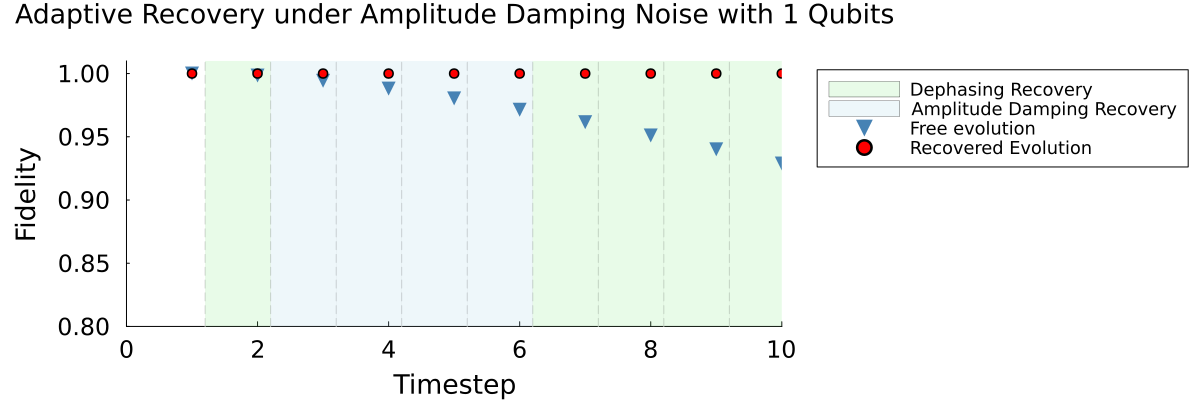

In [ ]:
plot_autorecovery(st, cfg, lgs; xlims=[0, total_steps])